In [24]:
import pandas
import numpy

dirty = pandas.read_csv("Data/combined_group_dataset.csv")

dirty.head(30)

,Observation ID,Name,Data Type,Latitude,Longitude,Color,Material,Town,Link to Picture,Open/Closed,Number of People,Price Range (CHF)
0,G1_R0,Solar Panel 1,Solar Panel,45.90187,8.97062,Black,crystalline silicon,Riva San Vitale,https://drive.google.com/file/d/1P91eS5RCPLk_T...,NaN,NaN,NaN
1,G1_R1,Statues 1,Statues,45.90440,8.97055,Pale off-white/cream,lime-plastered masonry,Riva San Vitale,https://drive.google.com/file/d/1tgSBeQguIu10f...,NaN,NaN,NaN
2,G1_R2,Solar Panel 2,Solar Panel,45.90696,8.97095,Black,crystalline silicon,Riva San Vitale,https://drive.google.com/file/d/1kngJeMCJY5VlB...,NaN,NaN,NaN
3,G1_R3,Floors 1,Floors/Bridges,45.90608,8.97254,Gray,Pre-cast concrete (cement + sand + crushed agg...,Riva San Vitale,https://drive.google.com/file/d/1y7Ue-Iqir3_Tj...,NaN,NaN,NaN
4,G1_R4,Floors 2,Floors/Bridges,45.90475,8.97052,Light Gray,natural igneous stone,Riva San Vitale,https://drive.google.com/file/d/1X3TihpIcc6KJD...,NaN,NaN,NaN
5,G1_R5,Fountain 1,Fountains,45.90572,8.97130,Light Gray,granite,Riva San Vitale,https://drive.google.com/file/d/1D0GOe--hKk6Vd...,NaN,NaN,NaN
6,G1_R6,Fountain 2,Fountains,45.90338,8.97015,Gray,porous calcareous stone,Riva San Vitale,https://drive.google.com/file/d/1Gyy81htRjRq1M...,NaN,NaN,NaN
7,G1_R7,Statues 2,Statues,45.90538,8.97110,Green,bronze,Riva San Vitale,https://drive.google.com/file/d/1o0Vgj0eUTNCNa...,NaN,NaN,NaN
8,G1_R8,Floors 3,Floors/Bridges,45.90533,8.97229,Light Gray,concrete,Riva San Vitale,https://drive.google.com/file/d/125CT2f_R9yzz8...,NaN,NaN,NaN
9,G1_R9,Floors 4,Floors/Bridges,45.90469,8.97089,Gray,limestone,Riva San Vitale,https://drive.google.com/file/d/1ZuanmT2az0urO...,NaN,NaN,NaN


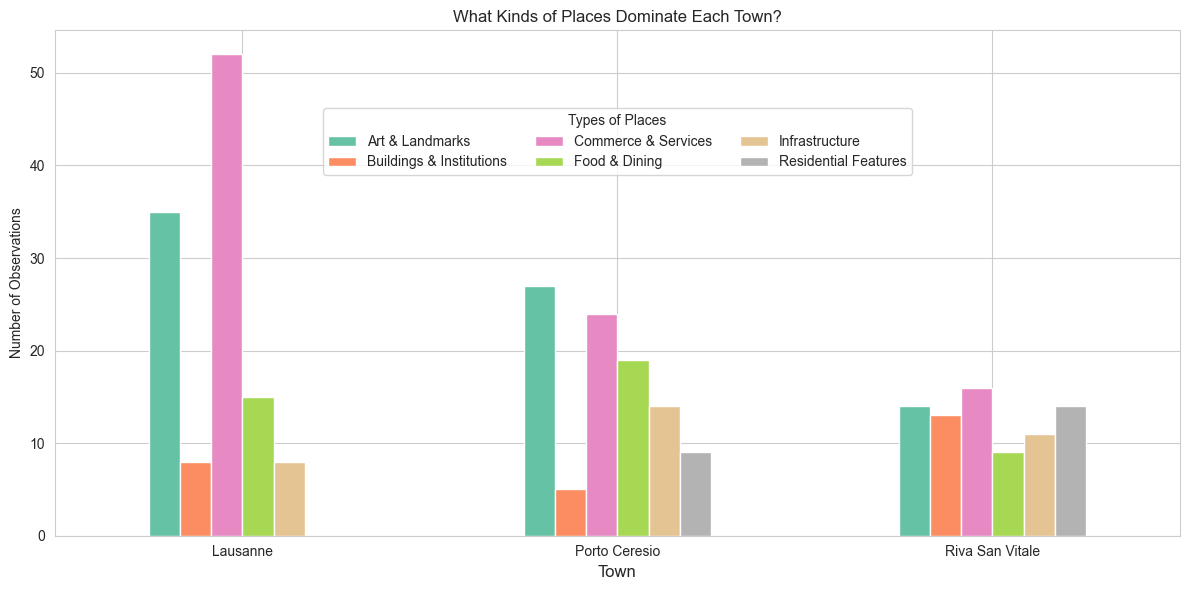

In [35]:
import matplotlib.pyplot as plt

dirty['Data Type'] = dirty['Data Type'].str.strip()
dirty['Data Type'] = dirty['Data Type'].replace({
    'Retail and Clothing': 'Retail & Clothing', 
    'Art ': 'Art', 
    ' Building': 'Building', 
    'Building ': 'Building'
})

subgroup_mapping = {
    # 1. Food & Dining
    'Restaurant': 'Food & Dining',
    
    # 2. Commerce & Services
    'Retail & Clothing': 'Commerce & Services',
    'Business Services': 'Commerce & Services',
    'Personal Care and Health': 'Commerce & Services',
    
    # 3. Art & Landmarks
    'Statues': 'Art & Landmarks',
    'Fountains': 'Art & Landmarks',
    'Art': 'Art & Landmarks',
    'Cultural': 'Art & Landmarks',
    'Art Studio': 'Art & Landmarks',
    
    # 4. Buildings & Institutions
    'Church': 'Buildings & Institutions',
    'Bell Tower': 'Buildings & Institutions',
    'School': 'Buildings & Institutions',
    'Building': 'Buildings & Institutions',
    
    # 5. Infrastructure
    'Floors/Bridges': 'Infrastructure',
    'Archways': 'Infrastructure',
    'Doors': 'Infrastructure',
    'Solar Panel': 'Infrastructure',
    
    # 6. Residential Detail
    'House Decoration': 'Residential Features'
}

dirty['Subgroup'] = dirty['Data Type'].map(subgroup_mapping)

counts = dirty.groupby(["Town", "Subgroup"]).size().unstack(fill_value=0)

ax = counts.plot(kind="bar", figsize=(12, 6), colormap='Set2') 

# 5. Formatting the Text
plt.title("What Kinds of Places Dominate Each Town?")
plt.ylabel("Number of Observations")
plt.xlabel("Town", fontsize=12)
plt.xticks(rotation=0)

ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.7), 
    ncol=3, 
    fontsize=10,
    title="Types of Places"
)

plt.tight_layout()
plt.show()